In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [ ]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44019,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36329,Total threads: 4
Dashboard: http://127.0.0.1:44491/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:46493,


2025-11-19 15:22:27,574 - distributed.nanny - WARNING - Restarting worker
2025-11-19 15:39:19,459 - distributed.nanny - WARNING - Restarting worker
2025-11-19 15:39:19,470 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:34151' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'shuffle-taker-66790f6ac11debd5be2bcb7920f2bf84'} (stimulus_id='handle-worker-cleanup-1763563159.4706118')
2025-11-19 15:39:19,477 - distributed.nanny - WARNING - Restarting worker
2025-11-19 15:47:28,810 - distributed.nanny - WARNING - Restarting worker
2025-11-19 17:25:46,834 - distributed.nanny - WARNING - Restarting worker
2025-11-19 17:25:56,390 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:46569' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('array-c72c7a3414e541992aa1f40c7a868428', 0)} (stimulus_id='handle-worker-cleanup-1763569556.3907545')
2025-11-19 17:25:56,403 - distributed.n

In [3]:
#client.close()

In [4]:
path_atm = "/nird/projects/NS1004K/elihho/NHIST_tropstratchem_20251116_fullset/atm/hist"
ds = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20251116_moved2iceland.cam.h0.*.nc", combine="by_coords", parallel=True)

In [5]:
path_atm_pin = "/projects/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_pin = xr.open_mfdataset(f"{path_atm_pin}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [6]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds['time'].values])
ds= ds.assign_coords(time=shifted_time)

print(ds["time"].values[:5])

[cftime.DatetimeNoLeap(1991, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1991, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1991, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1991, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1991, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


In [7]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_pin['time'].values])
ds_pin = ds_pin.assign_coords(time=shifted_time)
print(ds_pin["time"].values[:5])

[cftime.DatetimeNoLeap(1975, 1, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 2, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 3, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 4, 1, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1975, 5, 1, 0, 0, 0, 0, has_year_zero=True)]


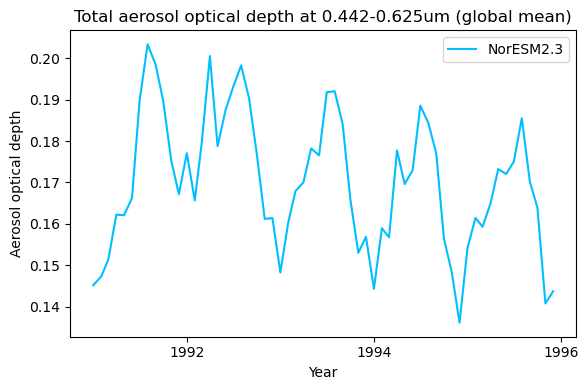

In [8]:
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

ts_aod = ds[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = ds[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
#ts_aod = ts_aod.resample(time="1YE").mean()

plt.figure(figsize=(6, 4))
ts_aod.plot(color = "deepskyblue", label = "NorESM2.3")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global mean)")
plt.legend()
plt.tight_layout()
plt.show()

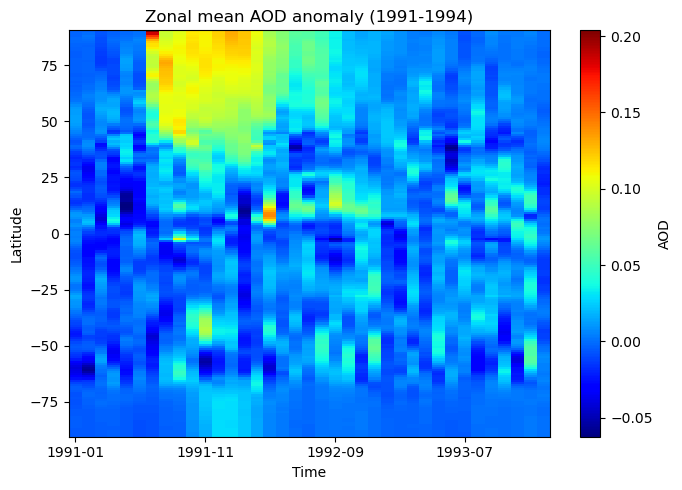

In [9]:
aod = ds[aod500]
daylight_monthly_nw = ds[daylight]
aod = aod / daylight_monthly_nw

baseline = aod.sel(time=slice("1994-01", "1996-12"))
base = baseline.groupby("time.month").mean("time")
aod_strat = aod.groupby("time.month") - base

aod_zoom = aod_strat.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom = aod_zoom['time'].values
aod_lat_time = aod_zoom.mean(dim="lon")
lat = aod_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    aod_lat_time.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="AOD")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean AOD anomaly (1991-1994)")
plt.tight_layout()
plt.show()

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarn

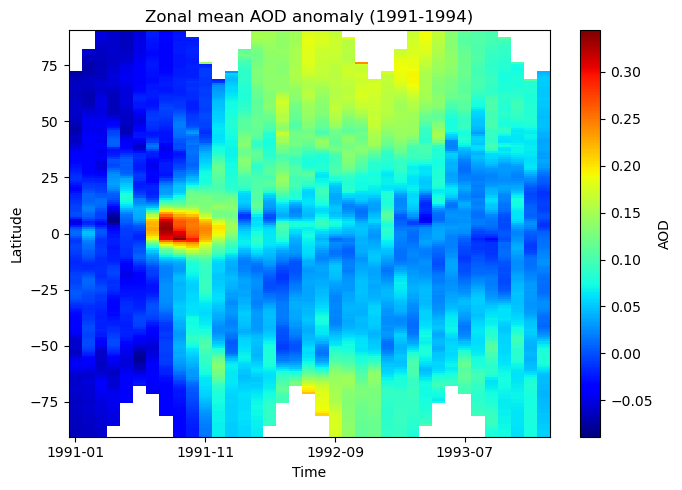

In [26]:
aod = ds_pin[aod500]
daylight_monthly_nw = ds_pin[daylight]
aod = aod / daylight_monthly_nw

baseline = aod.sel(time=slice("1994-01", "1996-12"))
base = baseline.groupby("time.month").mean("time")
aod_strat = aod.groupby("time.month") - base

aod_zoom = aod_strat.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom = aod_zoom['time'].values
aod_lat_time = aod_zoom.mean(dim="lon")
lat = aod_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    aod_lat_time.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="AOD")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean AOD anomaly (1991-1994)")
plt.tight_layout()
plt.show()

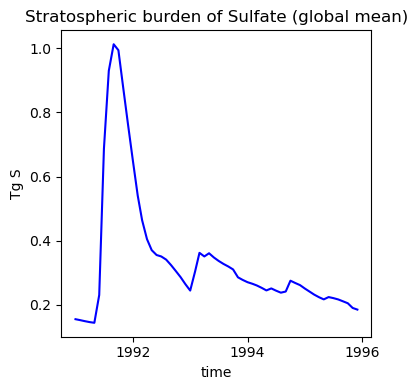

In [10]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
tropopause = ds["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
p_lev = tropopause * 0.01
M_strat_air = 0.099 * Matmos
Mo = 15.999
Mso4 = Ms + 4 * Mo
c = Ms / Mso4

mmr_sulf = ds["mmr_SULFATE"]
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd = so4_burd.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden = so4_burd * M_strat_air * 1e-12
so4_burden_TgS = so4_burden * c 

plt.figure(figsize=(4, 4))
so4_burden_TgS.plot(color = "blue", label = "NorESM2.3")
plt.ylabel("Tg S")
plt.title("Stratospheric burden of Sulfate (global mean)")
plt.tight_layout()

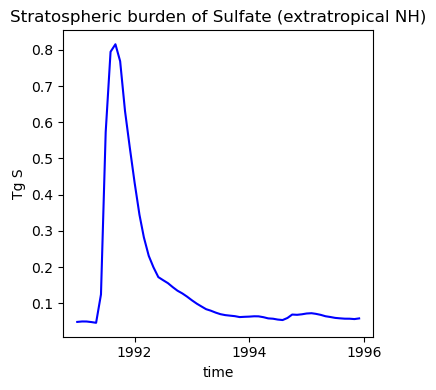

In [11]:
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
Mo = 15.999
Mso4 = Ms + (4 * Mo)
a_glob = 510000000
h_trop = 4440
d = 12756

a_trop = np.pi * d * h_trop
a_extratrop = (a_glob - a_trop)/2
ratio_etratrop = a_extratrop/a_glob

mmr_sulf = ds["mmr_SULFATE"]
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd_NH = so4_burd.sel(lat=slice(20, 90))
so4_burd_extratrop = so4_burd_NH.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden_extratrop = so4_burd_extratrop * M_strat_air * ratio_etratrop *10**(-12)
so4_burden_TgS_extratrop = so4_burden_extratrop * c

plt.figure(figsize=(4, 4))
so4_burden_TgS_extratrop.plot(color = "blue", label = "NorESM2.3")
plt.ylabel("Tg S")
plt.title("Stratospheric burden of Sulfate (extratropical NH)")
plt.tight_layout()

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (global mean)')

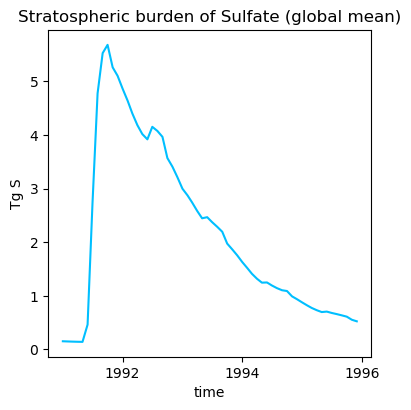

In [12]:
lat_pin = ds_pin["lat"]
weighted_lat_pin = np.cos(np.deg2rad(lat_pin))
tropopause = ds_pin["TROP_P"].weighted(weighted_lat_pin).mean(dim=["lat", "lon"])
p_lev = tropopause * 0.01

M_strat_air = 0.099 * Matmos
Mo = 15.999
Mso4 = Ms + 4 * Mo
c = Ms / Mso4

mmr_sulf_pin = ds_pin["mmr_SULFATE"]

so4_burd_pin = mmr_sulf_pin.where(mmr_sulf_pin["lev"] <= p_lev)
so4_burd_pin = so4_burd_pin.weighted(weighted_lat_pin).mean(dim=["lat", "lon", "lev"])
so4_burden_pin = so4_burd_pin * M_strat_air * 1e-12
so4_burden_TgS_pin = so4_burden_pin * c
so4_burden_TgS_pin_yr = so4_burden_TgS_pin.sel(time=slice("1991-01-01", "1995-12-31"))

plt.figure(figsize=(4,4))
so4_burden_TgS_pin_yr.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("Tg S")
plt.tight_layout()
plt.title("Stratospheric burden of Sulfate (global mean)")


Text(0.5, 1.0, 'Stratospheric burden of Sulfate (Tropics)')

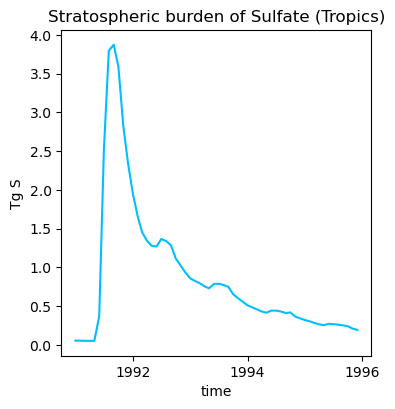

In [13]:
a_glob = 510000000
h_trop = 4440
d = 12756

a_trop = np.pi * d * h_trop
ratio = a_trop/a_glob

so4_trop = mmr_sulf_pin.sel(lat=slice(-20, 20))
so4_burd_trop = so4_trop.where(so4_trop["lev"] <= p_lev)
so4_burd_trop = so4_burd_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so4_burden_trop = so4_burd_trop * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop = so4_burden_trop * c
so4_burden_TgS_trop_Pin = so4_burden_TgS_trop.sel(time=[t for t in so4_burden_TgS_trop.time.values if 1991 <= t.year <= 1995])

plt.figure(figsize=(4, 4))
so4_burden_TgS_trop_Pin.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
plt.tight_layout()
plt.title("Stratospheric burden of Sulfate (Tropics)")

Exception ignored in: <function CachingFileManager.__del__ at 0x7ff01e567240>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


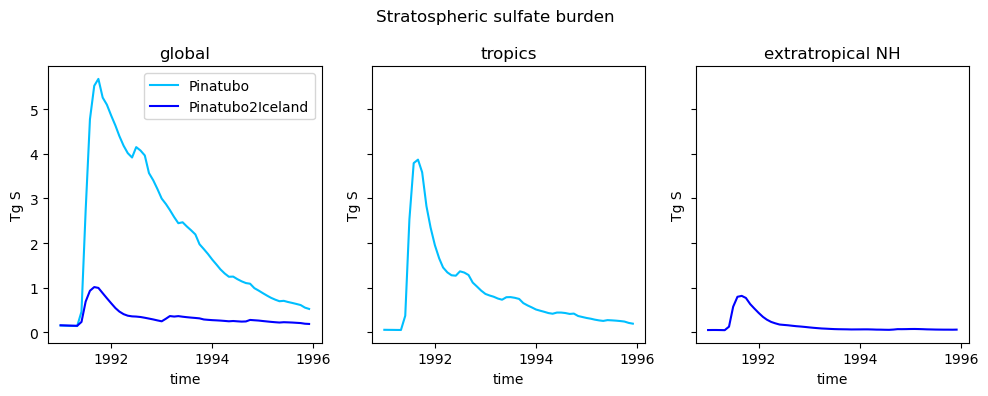

In [45]:
fig, axes = plt.subplots(1,3, figsize=(10, 4), sharey=True)

ax = axes[0]

so4_burden_TgS_pin_yr.plot(ax=ax, color="deepskyblue", label="Pinatubo")
so4_burden_TgS.plot(ax=ax, color="blue", label="Pinatubo2Iceland")
ax.set_title("global")
ax.set_ylabel("Tg S")
ax.legend()

ax = axes[1]
so4_burden_TgS_trop_Pin.plot(ax=ax, color="deepskyblue")
ax.set_title("tropics")
ax.set_ylabel("Tg S")

ax = axes[2]
so4_burden_TgS_extratrop.plot(ax=ax, color="blue")
ax.set_title("extratropical NH")
ax.set_ylabel("Tg S")

fig.suptitle("Stratospheric sulfate burden")
plt.tight_layout()
plt.show()


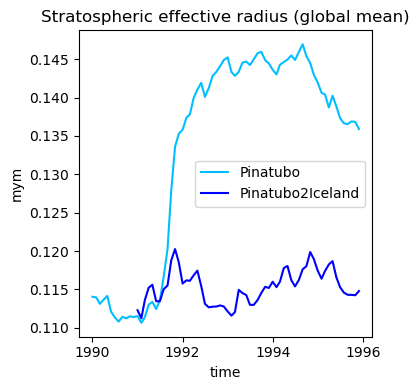

In [15]:
cm_to_mym = 10000
tropopause = ds["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
p_lev = tropopause * 0.01
SReff = ds["REFF_AERO"].where(ds["REFF_AERO"]["lev"] <= p_lev)
SReff = SReff.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])*cm_to_mym

tropopause_pin = ds_pin["TROP_P"].weighted(weighted_lat_pin).mean(dim=["lat", "lon"])
p_lev_pin = tropopause_pin * 0.01
SReff_pin = ds_pin["REFF_AERO"].where(ds_pin["REFF_AERO"]["lev"] <= p_lev_pin)
SReff_pin = SReff_pin.weighted(weighted_lat_pin).mean(dim=["lat", "lon", "lev"])*cm_to_mym
SReff_pin = SReff_pin.sel(time=slice("1990-01-01", "1995-12-31"))

plt.figure(figsize=(4, 4))
SReff_pin.plot(color = "deepskyblue", label = "Pinatubo")
SReff.plot(color = "blue", label = "Pinatubo2Iceland")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (global mean)")
plt.legend()
plt.tight_layout()

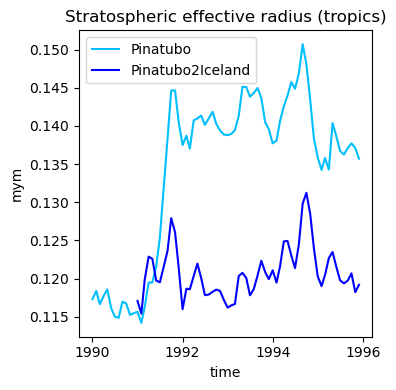

In [16]:
SReff = ds["REFF_AERO"].where(ds["REFF_AERO"]["lev"] <= p_lev)
SReff_trop = SReff.sel(lat = slice(-20,20))
SReff_trop = SReff_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"]) * cm_to_mym

SReff_pin = ds_pin["REFF_AERO"].where(ds_pin["REFF_AERO"]["lev"] <= p_lev_pin)
SReff_trop_pin = SReff_pin.sel(lat = slice(-20,20))
SReff_trop_pin = SReff_trop_pin.weighted(weighted_lat_pin).mean(dim=["lat", "lon", "lev"]) * cm_to_mym
SReff_trop_pin = SReff_trop_pin.sel(time=slice("1990-01-01", "1995-12-31"))

plt.figure(figsize=(4, 4))
SReff_trop_pin.plot(color = "deepskyblue", label = "Pinatubo")
SReff_trop.plot(color = "blue", label = "Pinatubo2Iceland")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (tropics)")
plt.legend()
plt.tight_layout()

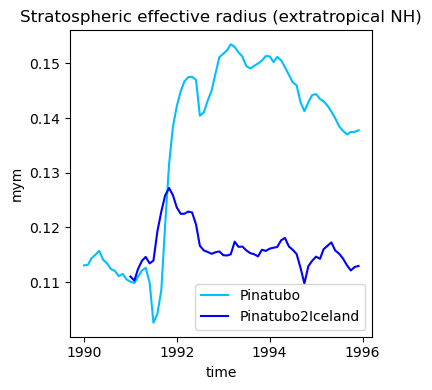

In [17]:
SReff = ds["REFF_AERO"].where(ds["REFF_AERO"]["lev"] <= p_lev)
SReff_nh = SReff.sel(lat = slice(20,90))
SReff_nh = SReff_nh.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"]) * cm_to_mym

SReff_pin = ds_pin["REFF_AERO"].where(ds_pin["REFF_AERO"]["lev"] <= p_lev_pin)
SReff_nh_pin = SReff_pin.sel(lat = slice(20,90))
SReff_nh_pin = SReff_nh_pin.weighted(weighted_lat_pin).mean(dim=["lat", "lon", "lev"]) * cm_to_mym
SReff_nh_pin = SReff_nh_pin.sel(time=slice("1990-01-01", "1995-12-31"))

plt.figure(figsize=(4, 4))
SReff_nh_pin.plot(color = "deepskyblue", label = "Pinatubo")
SReff_nh.plot(color = "blue", label = "Pinatubo2Iceland")
plt.ylabel("mym")
plt.title("Stratospheric effective radius (extratropical NH)")
plt.legend()
plt.tight_layout()

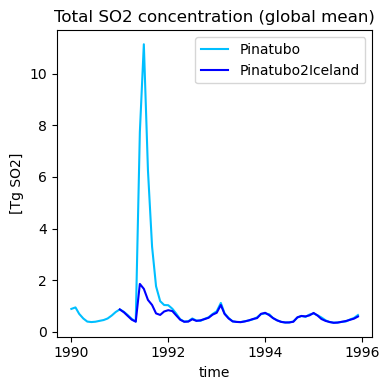

In [37]:
Ms = 32.065  
mso2 = 64.066   
M_air = 28.9647   
m_air_global = 5.3 * 10**21 
K = (Ms / M_air) * m_air_global *10**(-12)    # mol/mol → Tg conversion factor

# pinatubo2iceland
lat = ds["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
#background = so2.sel(time=slice("1993-01-01", "1995-12-31")).mean(dim="time")
#so2 = so2 - background

so2_tg = so2 * K

# pinatubo
so2_pin = ds_pin["SO2"].weighted(weighted_lat_pin).mean(dim=["lat", "lon", "lev"])
#background_pin = so2_pin.sel(time=slice("1993-01-01", "1995-12-31")).mean(dim="time")
#so2_pin = so2_pin - background_pin
so2_pin = so2_pin.sel(time=slice("1990-01-01", "1995-12-31"))

so2_tg_pin = so2_pin * K

plt.figure(figsize=(4, 4))
so2_tg_pin.plot(color="deepskyblue", label="Pinatubo")
so2_tg.plot(color="blue", label="Pinatubo2Iceland")
plt.ylabel("[Tg SO2]")
plt.title("Total SO2 concentration (global mean)")
plt.legend()
plt.tight_layout()
plt.show()

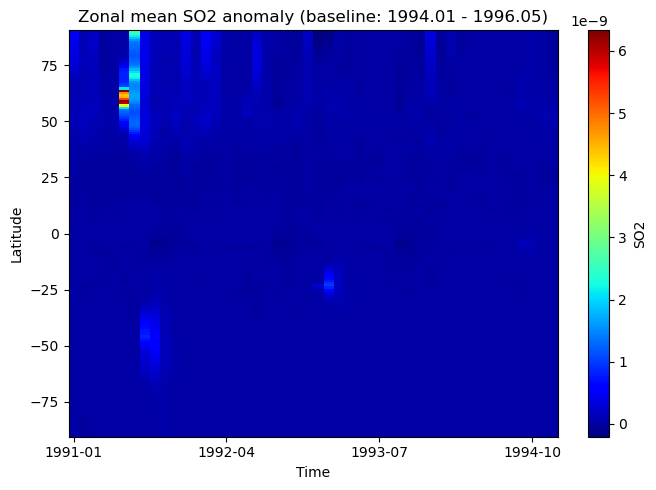

In [25]:
so2 = ds["SO2"].weighted(weighted_lat).mean(dim="lev")
pre_eruption = so2.sel(time=slice('1994-01-01', '1996-12-01'))
base = pre_eruption.groupby("time.month").mean()
so2_anom = so2.groupby("time.month") - base

so2_zoom = so2_anom.sel(time=slice('1991-01-01', '1994-12-01'))
time_zoom = so2_zoom['time'].values
so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    so2_lat_time.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="SO2")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2 anomaly (baseline: 1994.01 - 1996.05)")
plt.tight_layout()
plt.show()

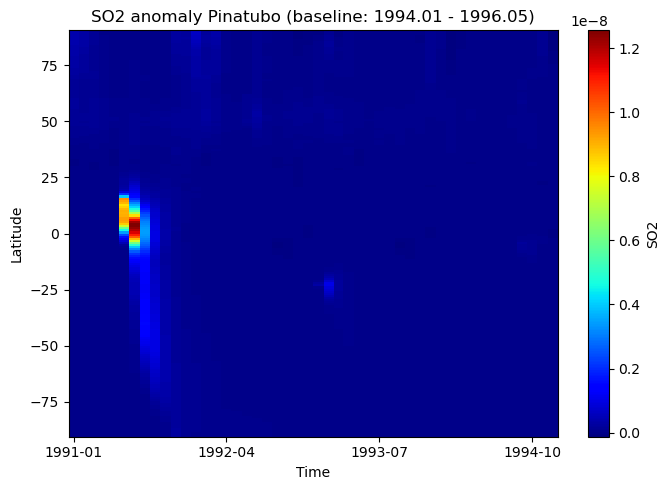

In [39]:
so2 = ds_pin["SO2"].weighted(weighted_lat_pin).mean(dim="lev")
pre_eruption = so2.sel(time=slice('1994-01-01', '1996-12-01'))
base = pre_eruption.groupby("time.month").mean()
so2_anom = so2.groupby("time.month") - base

so2_zoom = so2_anom.sel(time=slice('1991-01-01', '1994-12-01'))
time_zoom = so2_zoom['time'].values
so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    so2_lat_time.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label="SO2")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("SO2 anomaly Pinatubo (baseline: 1994.01 - 1996.05)")
plt.tight_layout()
plt.show()

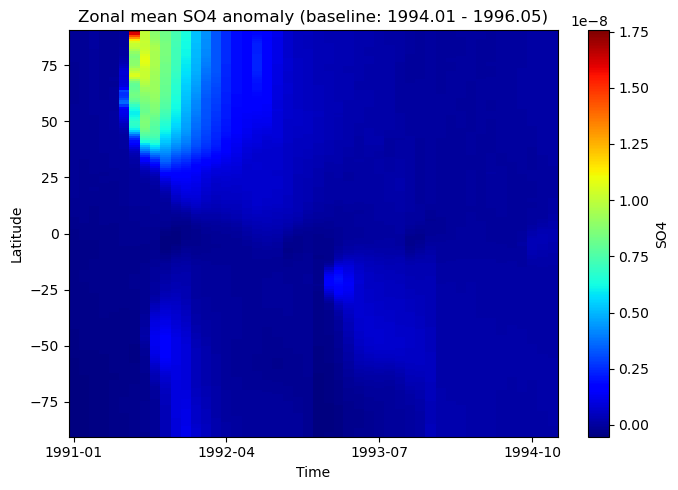

In [24]:
so4 = ds["mmr_SULFATE"].weighted(weighted_lat).mean(dim="lev")
pre_eruption = so4.sel(time=slice('1994-01-01', '1996-12-01'))
base = pre_eruption.groupby("time.month").mean()
so4_anom = so4.groupby("time.month") - base

so4_zoom = so4_anom.sel(time=slice('1991-01-01', '1994-12-01'))
time_zoom = so4_zoom['time'].values
so4_lat_time = so4_zoom.mean(dim="lon")
lat = so4_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    so4_lat_time.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label = "SO4")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO4 anomaly (baseline: 1994.01 - 1996.05)")
plt.tight_layout()
plt.show()

Exception ignored in: <function CachingFileManager.__del__ at 0x7ff01e567240>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


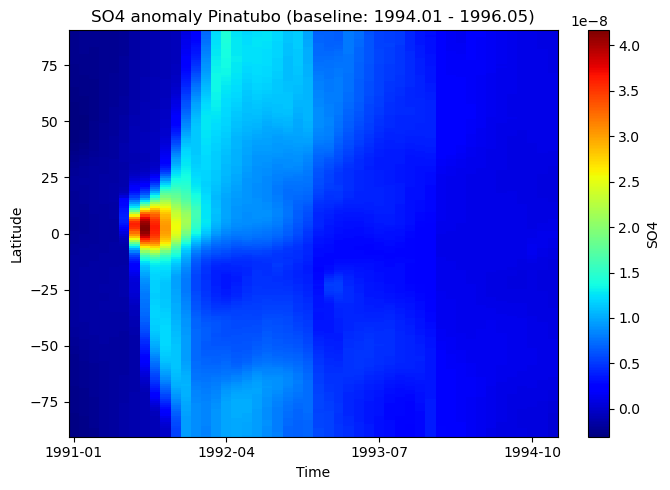

In [40]:
so4 = ds_pin["mmr_SULFATE"].weighted(weighted_lat_pin).mean(dim="lev")
pre_eruption = so4.sel(time=slice('1994-01-01', '1996-12-01'))
base = pre_eruption.groupby("time.month").mean()
so4_anom = so4.groupby("time.month") - base

so4_zoom = so4_anom.sel(time=slice('1991-01-01', '1994-12-01'))
time_zoom = so4_zoom['time'].values
so4_lat_time = so4_zoom.mean(dim="lon")
lat = so4_lat_time["lat"]

plt.figure(figsize=(7,5))
pc = plt.pcolormesh(
    time_zoom,
    lat,
    so4_lat_time.T, 
    shading="auto",  
    cmap="jet"
)

plt.colorbar(pc, label = "SO4")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("SO4 anomaly Pinatubo (baseline: 1994.01 - 1996.05)")
plt.tight_layout()
plt.show()